In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

In [5]:
df= pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\Loan-Credit-Analytics\dataset\Loan_Dataset.csv")
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Applicant_ID', 'Gender', 'Age', 'Marital_Status', 'Dependents', 'Education', 'Employment_Status', 'Occupation_Type', 'Residential_Status', 'City/Town', 'Annual_Income', 'Monthly_Expenses', 'Credit_Score', 'Existing_Loans', 'Total_Existing_Loan_Amount', 'Outstanding_Debt', 'Loan_History', 'Loan_Amount_Requested', 'Loan_Term', 'Loan_Purpose', 'Interest_Rate', 'Loan_Type', 'Co-Applicant', 'Bank_Account_History', 'Transaction_Frequency', 'Default_Risk', 'Loan_Approval_Status']


In [6]:
X = df.drop(
    ["Loan_Approval_Status", "Applicant_ID"],
    axis=1
)

y = df["Loan_Approval_Status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (52000, 25)
Target shape: (52000,)


In [7]:
numerical_features = [
    "Age",
    "Dependents",
    "Annual_Income",
    "Monthly_Expenses",
    "Credit_Score",
    "Existing_Loans",
    "Total_Existing_Loan_Amount",
    "Outstanding_Debt",
    "Loan_Amount_Requested",
    "Loan_Term",
    "Interest_Rate",
    "Bank_Account_History",
    "Transaction_Frequency",
    "Default_Risk"
]

categorical_features = [
    "Gender",
    "Marital_Status",
    "Education",
    "Employment_Status",
    "Occupation_Type",
    "Residential_Status",
    "City/Town",
    "Loan_History",
    "Loan_Purpose",
    "Loan_Type",
    "Co-Applicant"
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 14
Categorical features: 11


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (41600, 25)
Testing set: (10400, 25)


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [10]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(max_iter=1000)
        )
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [11]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_roc_auc, 4))

Logistic Regression
-------------------
Accuracy : 0.8507
Precision: 0.8503
Recall   : 0.9312
F1 Score : 0.8889
ROC-AUC  : 0.8152


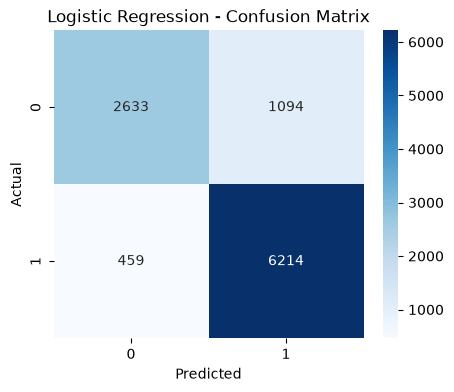

In [12]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Logistic Regression Evaluation

The Logistic Regression model achieved an accuracy of 85.07% on the test dataset. The model obtained a precision of 85.03%, recall of 93.12%, and an F1-score of 88.89%.

The ROC-AUC score of 81.52% indicates good discriminatory performance between approved and rejected loan applications.

Overall, Logistic Regression provides consistent predictive performance on the test dataset. It also achieved a marginally higher recall than the Random Forest model, indicating that it correctly identified a slightly larger proportion of approved applications.

In [13]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [14]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest
-------------
Accuracy : 0.8511
Precision: 0.851
Recall   : 0.9309
F1 Score : 0.8891
ROC-AUC  : 0.8203


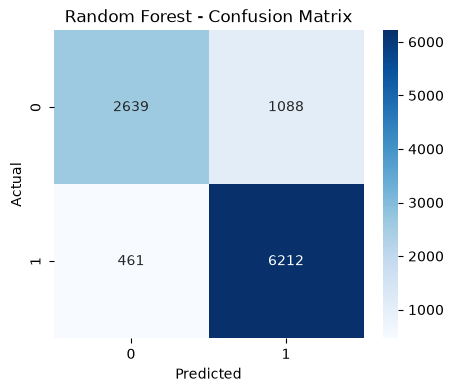

In [15]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest Evaluation

The Random Forest classifier achieved an accuracy of 85.11% on the test dataset. It obtained a precision of 85.10%, recall of 93.09%, and an F1-score of 88.91%.

The ROC-AUC score of 82.03% indicates that the model has good ability to distinguish between approved and rejected loan applications.

The Random Forest model performed slightly better than Logistic Regression in terms of accuracy, precision, F1-score, and ROC-AUC, while Logistic Regression achieved a marginally higher recall.

Overall, the Random Forest model demonstrated consistent and realistic predictive performance on the test dataset and was selected as the final model for the Loan Approval Prediction System.

In [16]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1,
        lr_roc_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.850673,0.851058
1,Precision,0.850301,0.850959
2,Recall,0.931215,0.930916
3,F1 Score,0.888921,0.889143
4,ROC-AUC,0.815168,0.820254


In [17]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["classifier"]

feature_names = rf_preprocessor.get_feature_names_out()

importances = rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,num__Credit_Score,0.211834
8,num__Loan_Amount_Requested,0.183090
2,num__Annual_Income,0.110275
0,num__Age,0.069462
10,num__Interest_Rate,0.038224
7,num__Outstanding_Debt,0.037987
3,num__Monthly_Expenses,0.037705
6,num__Total_Existing_Loan_Amount,0.037484
9,num__Loan_Term,0.035441
13,num__Default_Risk,0.033607


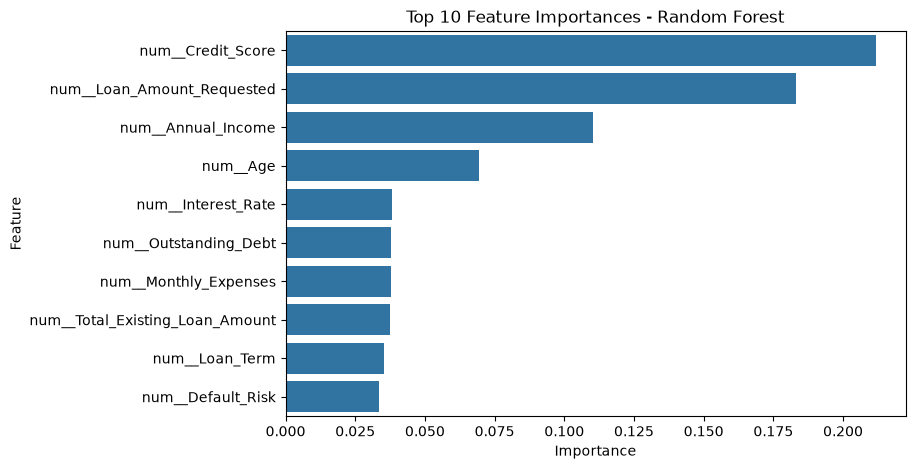

In [18]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Feature Importance

The Random Forest model identifies **Credit Score** as the most important feature for predicting loan approval, with an importance of approximately **21.18%**. **Loan Amount Requested** and **Annual Income** are the next most influential features, with importance values of approximately **18.31%** and **11.03%**, respectively. Other important factors include **Age, Interest Rate, Outstanding Debt, Monthly Expenses, Total Existing Loan Amount, Loan Term, and Default Risk**.

The feature importance results are consistent with the EDA, which highlighted **Credit Score, Annual Income, and Loan Amount Requested** as important variables associated with loan approval. These results indicate that the model considers multiple applicant and loan-related factors rather than relying heavily on a single feature.


In [21]:
import os
import joblib

model_path = "../models/loan_approval_random_forest.pkl"

os.makedirs("../models", exist_ok=True)

joblib.dump(
    random_forest_model,
    model_path
)

print("Model saved successfully:")
print(os.path.abspath(model_path))

Model saved successfully:
c:\Users\USER\OneDrive\Desktop\Loan-Credit-Analytics\models\loan_approval_random_forest.pkl


In [22]:
new_applicant = pd.DataFrame({
    "Gender": ["Male"],
    "Age": [35],
    "Marital_Status": ["Married"],
    "Dependents": [2],
    "Education": ["Graduate"],
    "Employment_Status": ["Employed"],
    "Occupation_Type": ["Salaried"],
    "Residential_Status": ["Own"],
    "City/Town": ["Urban"],
    "Annual_Income": [90000],
    "Monthly_Expenses": [3000],
    "Credit_Score": [750],
    "Existing_Loans": [1],
    "Total_Existing_Loan_Amount": [20000],
    "Outstanding_Debt": [10000],
    "Loan_History": [1],
    "Loan_Amount_Requested": [25000],
    "Loan_Term": [120],
    "Loan_Purpose": ["Home"],
    "Interest_Rate": [7.5],
    "Loan_Type": ["Secured"],
    "Co-Applicant": ["Yes"],
    "Bank_Account_History": [7],
    "Transaction_Frequency": [20],
    "Default_Risk": [0.15]
})

prediction = random_forest_model.predict(new_applicant)[0]

probability = random_forest_model.predict_proba(
    new_applicant
)[0][1]

if prediction == 1:
    result = "Approved"
else:
    result = "Rejected"

print("Loan Approval Prediction:", result)
print("Approval Probability:", round(probability * 100, 2), "%")

Loan Approval Prediction: Approved
Approval Probability: 93.0 %


## New Applicant Prediction

A sample applicant was provided to the trained Random Forest model to demonstrate the loan approval prediction workflow.

The model predicted the applicant as **Approved** with an approval probability of **93.0%**.

This demonstrates how the trained model can be used to evaluate a new loan application based on the applicant's financial, demographic, employment, and loan-related characteristics.